# 1. OpenAI VLM (GPT) - Basics
This section demonstrates the basic usage of OpenAI's Vision Language Model (VLM) capabilities using GPT-4.1.
We will use the OpenAI API to analyze an image and provide detailed textual insights.

**Reference Material**

- https://developers.openai.com/api/docs/quickstart?language=python
- https://platform.openai.com/docs/guides/text
- https://platform.openai.com/docs/guides/images-vision?api-mode=chat
- https://platform.openai.com/docs/guides/structured-outputs

In [1]:
from openai import OpenAI
from dotenv import load_dotenv  
import base64
import textwrap

# Function to encode the image
def encode_image(image_path):
  with open(image_path, "rb") as image_file:
    return base64.b64encode(image_file.read()).decode('utf-8')


load_dotenv()

openai_client = OpenAI()

In [2]:
# Basic call to GPT with a prompt and an image
# Example from: https://developers.openai.com/api/docs/quickstart/?lang=python

response = openai_client.responses.create(
    model="gpt-5",
    input=[
        {
            "role": "user",
            "content": [
                {
                    "type": "input_text",
                    "text": "What teams are playing in this image?",
                },
                {
                    "type": "input_image",
                    "image_url": "https://api.nga.gov/iiif/a2e6da57-3cd1-4235-b20e-95dcaefed6c8/full/!800,800/0/default.jpg"
                }
            ]
        }
    ]
)

print(response.output_text)

None. This is a portrait painting of a seated person, not a sports scene.


In [3]:
# Path to your image
img = "images/street_scene.jpg"

response = openai_client.responses.create(
    model="gpt-4.1-mini",
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": "What's in this image?"},
                {
                    "type": "input_image",
                    "image_url": f"data:image/jpeg;base64,{encode_image(img)}"
                }
            ],
        }
    ],
)

print(textwrap.fill(response.output_text, width=120))

The image depicts a lively urban street scene with several people engaged in different activities. On the right side,
there is a wooden bench where an elderly man in a suit is sitting while a woman with short blonde hair, wearing a red
top and blue jeans, is reading a newspaper. A young woman in a pink top and shorts is walking nearby.  In the
foreground, a young person with short hair is sitting on the ground playing on a tablet or mobile device, and another
person is lying down on the pavement wearing a red jacket and blue jeans.  There are pigeons scattered around the
pavement area. On the crosswalk, a man wearing a black cap and dark clothes is playing a guitar while standing.
Additionally, a motorcycle rider wearing a helmet and a person on a scooter are crossing the street, and a few cars are
visible on the road.  The background shows a bustling cityscape with tall skyscrapers, a historic building with a spire,
trees, and a traffic light suspended above the intersection. The atmo

# 1.1 JSON Schema for Controlled Structured Outputs
In this section, we define a JSON schema for a more controlled and specific model output.
Using this schema, we can ensure the model adheres to predefined data types and structures while describing images.
In this case, we provide the JSON schema directly.

**Reference Material**:
- Data Validation: https://docs.pydantic.dev/latest/
- https://platform.openai.com/docs/guides/structured-outputs

In [4]:
from openai import OpenAI
from pydantic import BaseModel, Field
from typing import List, Literal

client = OpenAI()


class Person(BaseModel):
    position: str
    age: int = Field(ge=0)
    activity: str
    hair_color: str
    gender: Literal["male", "female", "non-binary", "other", "prefer not to say"]


class ImageExtract(BaseModel):
    numberOfPeople: int = Field(ge=0)
    atmosphere: str
    hourOfTheDay: int = Field(ge=0, le=23)
    people: List[Person]


response = client.responses.parse(
    model="gpt-4.1-mini",
    temperature=0,
    text_format=ImageExtract,
    input=[
        {
            "role": "system",
            "content": [
                {
                    "type": "input_text",
                    "text": "You are a careful observer."
                }
            ],
        },
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": "Describe the image in detail"},
                {
                    "type": "input_image",
                    "image_url": f"data:image/jpeg;base64,{encode_image(img)}"
                },
            ],
        },
    ],
)

result: ImageExtract = response.output_parsed

In [5]:
print(result.model_dump_json(indent=2))

{
  "numberOfPeople": 10,
  "atmosphere": "Busy urban street scene with a mix of calm and movement, during what appears to be late afternoon or early evening with warm sunlight.",
  "hourOfTheDay": 17,
  "people": [
    {
      "position": "sitting on the ground near a flower pot",
      "age": 16,
      "activity": "using a smartphone",
      "hair_color": "brown",
      "gender": "male"
    },
    {
      "position": "lying on the ground near the crosswalk",
      "age": 18,
      "activity": "resting or sleeping",
      "hair_color": "black",
      "gender": "male"
    },
    {
      "position": "walking across the street playing guitar",
      "age": 30,
      "activity": "playing guitar",
      "hair_color": "black",
      "gender": "male"
    },
    {
      "position": "riding a motorcycle across the street",
      "age": 25,
      "activity": "riding motorcycle",
      "hair_color": "not visible due to helmet",
      "gender": "male"
    },
    {
      "position": "riding a scoo

In [6]:
for person in result.people:
    print(person.position, person.activity, person.age)

sitting on the ground near a flower pot using a smartphone 16
lying on the ground near the crosswalk resting or sleeping 18
walking across the street playing guitar playing guitar 30
riding a motorcycle across the street riding motorcycle 25
riding a scooter across the street riding scooter 28
sitting on a bench reading a newspaper reading newspaper 65
sitting on a bench reading a newspaper reading newspaper 30
walking on the sidewalk near the bench looking at phone 22
inside a taxi car driving 40
inside a taxi car passenger 35


We can then integrate all or part of the extracted information into a new prompt for a follow-up extraction.

In [7]:
# Alert service prompt
class AlertAssessment(BaseModel):
    anyone_in_danger: bool
    alert_hospital: bool
    hospital_type: Literal["none", "child_hospital", "normal_hospital"]
    concise_reason: str
    
alert_sys_prompt = "You are an experienced first-aid paramedic."
alert_prompt = (
    "Given this scene analysis, determine whether anyone might be in danger and "
    "whether a child hospital or a normal hospital should be alerted. "
    "Respond concisely and conservatively. "
    "If the evidence is uncertain, say so.\n\n"
    f"Scene analysis:\n{result.model_dump_json(indent=2)}"
)

In [8]:
alert_response = client.responses.parse(
    model="gpt-4.1-mini",
    input=[
        {
            "role": "system",
            "content": [{"type": "input_text", "text": alert_sys_prompt}],
        },
        {
            "role": "user",
            "content": [{"type": "input_text", "text": alert_prompt}],
        },
    ],
    text_format=AlertAssessment,
)

alert_result: AlertAssessment = alert_response.output_parsed

print(alert_result.model_dump_json(indent=2))
print(textwrap.fill(alert_result.concise_reason, width=120))

{
  "anyone_in_danger": false,
  "alert_hospital": false,
  "hospital_type": "none",
  "concise_reason": "No clear signs of injury or distress; all individuals appear engaged in normal activities without apparent emergency."
}
No clear signs of injury or distress; all individuals appear engaged in normal activities without apparent emergency.


In [9]:

# ---- Youngest-person localization models ----

class Box2DResult(BaseModel):
    person_description: str
    estimated_age: int = Field(ge=0)
    box_2d: List[int] = Field(
        description="Normalized [ymin, xmin, ymax, xmax] coordinates in range 0-1000"
    )


youngest_prompt = (
    "Considering this list of people:\n"
    f"{result.model_dump_json(indent=2)}\n\n"
    "Identify the youngest person in the image and return their coordinates. "
    "The box_2d must be [ymin, xmin, ymax, xmax], normalized to 0-1000. "
    "Return only the structured result."
)

youngest_response = client.responses.parse(
    model="gpt-4.1-mini",
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": youngest_prompt},
                {
                    "type": "input_image",
                    "image_url": f"data:image/jpeg;base64,{encode_image(img)}",
                },
            ],
        }
    ],
    text_format=Box2DResult,
)

youngest_result: Box2DResult = youngest_response.output_parsed

print(youngest_result.model_dump_json(indent=2))

{
  "person_description": "Male, 16 years old, sitting on the ground near a flower pot, using a smartphone.",
  "estimated_age": 16,
  "box_2d": [
    715,
    95,
    850,
    300
  ]
}


In [10]:
img

'images/street_scene.jpg'

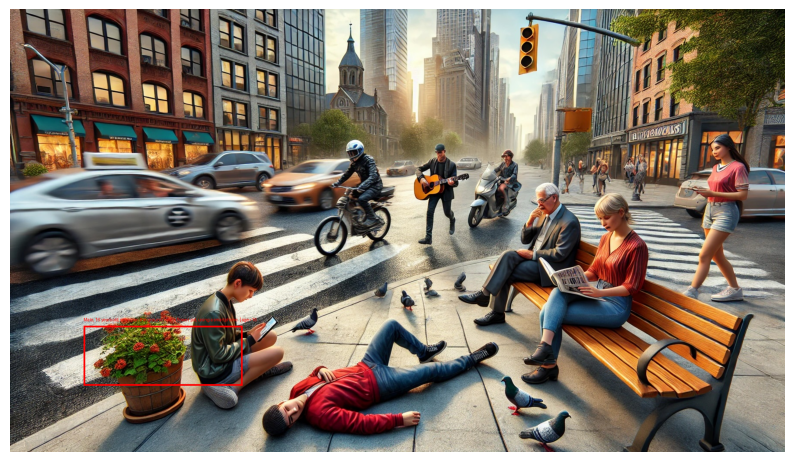

In [11]:
from PIL import ImageDraw, Image
import matplotlib.pyplot as plt

def visualize_detection(img_path, detection):
    img = Image.open(img_path).convert("RGB")
    width, height = img.size
    
    ymin, xmin, ymax, xmax = detection.box_2d

    x1 = int(xmin / 1000 * width)
    y1 = int(ymin / 1000 * height)
    x2 = int(xmax / 1000 * width)
    y2 = int(ymax / 1000 * height)

    draw = ImageDraw.Draw(img)
    draw.rectangle([x1, y1, x2, y2], outline="red", width=4)

    label = f"{detection.person_description} | age={detection.estimated_age}"
    draw.text((x1, max(0, y1 - 20)), label, fill="red")

    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()


visualize_detection(img, youngest_result)

# 2. Google VLM (Gemini)
This section demonstrates the use of Google's Vision Language Model, Gemini.
We explore basic text generation as well as image analysis capabilities and structured outputs.

**Reference Material**:
- https://ai.google.dev/gemini-api/docs/quickstart
- https://ai.google.dev/gemini-api/docs/text-generation
- https://ai.google.dev/gemini-api/docs/image-understanding
- https://ai.google.dev/gemini-api/docs/structured-output?example=recipe

In [12]:
from dotenv import load_dotenv
from google import genai
from PIL import Image
import textwrap

import json


load_dotenv()
client = genai.Client()

# Path to your image
img = "images/street_scene.jpg"

Basic call:

In [13]:
response = client.models.generate_content(
    model="gemini-2.5-flash", contents="Explain how AI works to a 90-year-old in a few words."
)

print(textwrap.fill(response.text, width=120))

It's like a computer that learns from countless examples, just like a person learns from experience, to make smart
decisions or solve problems.


And with images:

In [14]:
im = Image.open(img)

response = client.models.generate_content(model="gemini-2.5-flash",
                                          contents=[im, "Describe the scene in detail.\n"],
                                          )

print(textwrap.fill(response.text, width=120))

This vibrant image captures a bustling city street scene at what appears to be late afternoon or "golden hour," given
the warm, long shadows and bright sunlight illuminating the background buildings. The composition is dynamic, with a mix
of static and motion-blurred elements, creating a sense of constant activity.  **In the Foreground:** On the immediate
left, a large wooden pot overflowing with bright red flowers sits on the sidewalk. Next to it, a young person with short
hair, wearing an olive-green jacket and shorts, sits cross-legged on the pavement, engrossed in a tablet or phone.
Further into the center, another young man, dressed in a red hoodie and blue jeans, lies flat on his back on the
concrete sidewalk, looking upwards. Several pigeons are scattered around these individuals, some pecking at the ground,
others simply standing.  On the right side of the foreground, a sturdy wooden park bench with black metal supports holds
two individuals. An older man with glasses, dressed 

We can also extract structured output (Gemini generally prefers Pydantic syntax).
Let's see how it behaves with a schema like before. See limitations: https://ai.google.dev/gemini-api/docs/structured-output?example=recipe

In [15]:
from pydantic import BaseModel, Field
from typing import List, Literal

class Person(BaseModel):
    position: str
    age: int = Field(ge=0)
    activity: str
    gender: Literal["male", "female", "non-binary", "other", "prefer not to say"]

class ImageExtract(BaseModel):
    numberOfPeople: int = Field(ge=0)
    atmosphere: str
    hourOfTheDay: int = Field(ge=0, le=23)
    people: List[Person]
    
    
json_schema = ImageExtract.model_json_schema()

config = {
    "response_mime_type": "application/json",
    "response_json_schema": json_schema
}

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=[
        im,
        "Describe the scene in detail and follow the given JSON schema exactly."
    ],
    config=config
)

print(response.text)

{
  "numberOfPeople": 8,
  "atmosphere": "A bustling urban street scene during late afternoon, with a mix of pedestrians, vehicles, and pigeons, under golden sunlight creating long shadows.",
  "hourOfTheDay": 18,
  "people": [
    {
      "position": "Sitting cross-legged on the sidewalk next to a potted plant, near the zebra crossing.",
      "age": 13,
      "activity": "Looking at and interacting with a tablet device.",
      "gender": "male"
    },
    {
      "position": "Lying on his back on the sidewalk, near a group of pigeons.",
      "age": 25,
      "activity": "Resting or relaxing on the ground.",
      "gender": "male"
    },
    {
      "position": "Riding a motorcycle across the zebra crossing in motion.",
      "age": 30,
      "activity": "Driving a motorcycle.",
      "gender": "male"
    },
    {
      "position": "Walking on the zebra crossing, holding a guitar.",
      "age": 32,
      "activity": "Walking and carrying a guitar.",
      "gender": "male"
    },
   

In [16]:
import json

data = json.loads(response.text)

result = ImageExtract(**data)

print(result)
print(result.people[0].activity)

numberOfPeople=8 atmosphere='A bustling urban street scene during late afternoon, with a mix of pedestrians, vehicles, and pigeons, under golden sunlight creating long shadows.' hourOfTheDay=18 people=[Person(position='Sitting cross-legged on the sidewalk next to a potted plant, near the zebra crossing.', age=13, activity='Looking at and interacting with a tablet device.', gender='male'), Person(position='Lying on his back on the sidewalk, near a group of pigeons.', age=25, activity='Resting or relaxing on the ground.', gender='male'), Person(position='Riding a motorcycle across the zebra crossing in motion.', age=30, activity='Driving a motorcycle.', gender='male'), Person(position='Walking on the zebra crossing, holding a guitar.', age=32, activity='Walking and carrying a guitar.', gender='male'), Person(position='Riding a scooter on the street, behind the man with the guitar.', age=40, activity='Driving a scooter.', gender='female'), Person(position='Sitting on a wooden park bench o

Does it match your schema?

Let's use Gemini to detect an object in the image and return its coordinates:

In [17]:
from pydantic import BaseModel, Field
from typing import List

class Box2DResult(BaseModel):
    person_description: str
    estimated_age: int = Field(ge=0)
    box_2d: List[int] = Field(
        description="Normalized [ymin, xmin, ymax, xmax] coordinates in range 0-1000"
    )

import json

schema = Box2DResult.model_json_schema()

config = {
    "response_mime_type": "application/json",
    "response_json_schema": schema
}

youngest_prompt = (
    "Considering this list of people:\n"
    f"{result.model_dump_json(indent=2)}\n\n"
    "Identify the youngest person in the image and return their coordinates. "
    "The box_2d must be [ymin, xmin, ymax, xmax], normalized to 0-1000. "
    "Return only the structured result."
)

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=[img, youngest_prompt],
    config=config
)

data = json.loads(response.text)

result = Box2DResult(**data)

print(result)

person_description='A 13-year-old male sitting cross-legged on the sidewalk, next to a potted plant, near the zebra crossing, interacting with a tablet device.' estimated_age=13 box_2d=[685, 180, 850, 270]


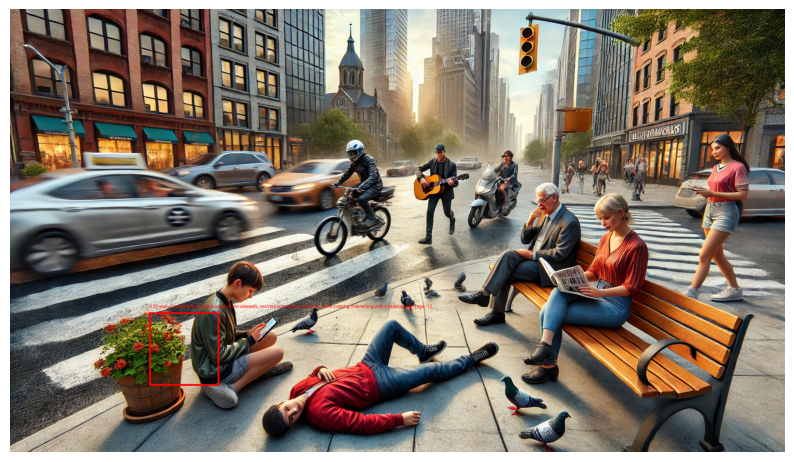

In [18]:
visualize_detection(img, result)

Gemini 2+ was trained specifically for object detection and segmentation tasks.

More details: https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb

## 3. Extract Structured Information from a Handwritten Note - GPT & Gemini

Let's extract structured information from a handwritten note (e.g., `prescription1.jpg`) using both models.

Consider the file: `/images/prescription1.jpg`.
Take a look at it.

### JSON Schema
Let's define a JSON schema for the extraction task:

In [19]:
json_schema_prescription = {
 "name": "prescription_extract",
"schema": {
  "type": "object",
  "properties": {
    "doctor_name": { "type": "string" },
    "patient_name": { "type": "string" },
    "patient_dob": { "type": "string" },
    "meds": {
      "type": "array",
      "items": {
        "type": "object",
        "properties": {
          "name": { "type": "string" },
          "dose": { "type": "string" },
          "frequency": { "type": "string" },
          "instructions": { "type": "string" }
        },
        "required": ["name"]
      }
    },
    "signature": { "type": "boolean" }
  },
  "required": ["doctor_name", "patient_name", "meds"]
}}

## TODO
- Extract once with OpenAI and once with Google Gemini using Pydantic validation (https://docs.pydantic.dev/latest/).

Extract structured information using Gemini:

In [22]:
from pydantic import BaseModel, Field
from typing import List
import json

class Medication(BaseModel):
    name: str
    dose: str = ""
    frequency: str = ""
    instructions: str = ""

class PrescriptionExtract(BaseModel):
    doctor_name: str
    patient_name: str
    patient_dob: str = ""
    meds: List[Medication]
    signature: bool = False

# Load and prepare image
im = Image.open("images/prescription1.jpg")

# Create JSON schema from Pydantic model
schema = PrescriptionExtract.model_json_schema()

config = {
    "response_mime_type": "application/json",
    "response_json_schema": schema
}

# Extract using Gemini
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=[
        im,
        "Extract all information from this prescription following the JSON schema exactly. "
        "Include doctor name, patient name, date of birth, all medications with doses and frequency, "
        "and whether a signature is present."
    ],
    config=config
)

# Parse and validate
gemini_data = json.loads(response.text)
gemini_result = PrescriptionExtract(**gemini_data)

print("Gemini Extraction Result:")
print(gemini_result.model_dump_json(indent=2))

Gemini Extraction Result:
{
  "doctor_name": "Dr. Markus Hüller",
  "patient_name": "Claudia Fischer",
  "patient_dob": "1.4.1978",
  "meds": [
    {
      "name": "Ibuprofen",
      "dose": "400mg",
      "frequency": "3x",
      "instructions": "nach dem Essen"
    }
  ],
  "signature": true
}


Now let's do the same with GPT.

In [23]:
# Extract using OpenAI
gpt_response = openai_client.responses.parse(
    model="gpt-4.1-mini",
    input=[
        {
            "role": "user",
            "content": [
                {
                    "type": "input_text",
                    "text": "Extract all information from this prescription following the schema exactly. "
                    "Include doctor name, patient name, date of birth, all medications with doses and frequency, "
                    "and whether a signature is present."
                },
                {
                    "type": "input_image",
                    "image_url": f"data:image/jpeg;base64,{encode_image('images/prescription1.jpg')}"
                }
            ],
        }
    ],
    text_format=PrescriptionExtract,
)

gpt_result = gpt_response.output_parsed

print("OpenAI GPT Extraction Result:")
print(gpt_result.model_dump_json(indent=2))

OpenAI GPT Extraction Result:
{
  "doctor_name": "Dr. Markus Müller",
  "patient_name": "Claudia Fischer",
  "patient_dob": "1.4.1978",
  "meds": [
    {
      "name": "Ibuprofen",
      "dose": "400mg",
      "frequency": "3x",
      "instructions": "nach dem Essen"
    }
  ],
  "signature": true
}


Any differences between the Gemini and OpenAI outputs?